In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_model_optimization as tfmot #     [TFMOT] Nhúng thư viện tối ưu hóa
import numpy as np
import pandas as pd
import glob
from PIL import Image

# ==========================================
# CẤU HÌNH THÔNG SỐ
# ==========================================
#! ĐỪNG ĐỤNG
IMG_SIZE = 32
NUM_CLASSES = 10
# ĐỤNG ĐƯỢC
EPOCHS = 100
BATCH_SIZE = 8
DROPOUT_RATE = 0.3
EASTOP = 30
REDUCELR = 6
MINLR = 0.5e-6
VAL_SPLIT = 0.3
DENSE = 64
ALPHA= 0.5
MONITOR = 'val_accuracy'

# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomContrast(0.1, seed=123),
    layers.RandomZoom(0.05, seed=123, fill_mode='nearest'),      
    layers.RandomRotation(0.05, seed=123, fill_mode='nearest'),
    layers.RandomTranslation(0.05, 0.05, seed=123, fill_mode='nearest'), 
    layers.RandomBrightness(factor=0.05, value_range=(0.0, 1.0), seed=123)
])

# ĐƯỜNG DẪN DATASET (Bạn sẽ cập nhật sau)
TRAIN_DIR = 'C:/DUT/Ki_2/Edge_AI/dataset/train'
TEST_DIR = 'C:/DUT/Ki_2/Edge_AI/dataset/test'

# ==========================================
# NẠP VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

normalization_layer = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    train_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .cache()  # Cache dữ liệu đã chuẩn hóa (0-1) để tiết kiệm CPU tính toán lại
    .shuffle(buffer_size=len(train_ds) * BATCH_SIZE) # Xáo trộn các Batch (vì data đã là batch rồi)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE) # Augment sau Cache để mỗi Epoch ảnh mỗi khác
    .prefetch(buffer_size=AUTOTUNE) # Chuẩn bị sẵn dữ liệu cho GPU
)
val_ds = (
    val_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

def make_divisible(v, divisor=16, min_value=None):
    """
    Đảm bảo mọi lớp đều có số lượng filter chia hết cho `divisor` (16).
    """
    if min_value is None:
        min_value = divisor
    # Công thức làm tròn đến bội số gần nhất
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    # Đảm bảo việc làm tròn xuống không làm mất quá 10% số lượng filter
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

def build_micro_model():
    model = models.Sequential([
        layers.InputLayer(input_shape=(32, 32, 1)),

        layers.Conv2D(make_divisible(32 * ALPHA), (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu6'),
        layers.MaxPooling2D((2, 2)),
        
        layers.SeparableConv2D(make_divisible(64 * ALPHA), (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu6'),
        layers.MaxPooling2D((2, 2)),
        
        layers.SeparableConv2D(make_divisible(128 * ALPHA), (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu6'),
        layers.MaxPooling2D((2, 2)),

        layers.SeparableConv2D(make_divisible(128 * ALPHA), (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu6'),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# Khởi tạo model gốc
base_model = build_micro_model()

# ==========================================
# CUSTOM CALLBACK & COMPILE
# ==========================================
class AccuracyTracker(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_acc = 0.0
        self.best_val_loss = 10.0

    def on_epoch_end(self, epoch, logs=None):
        current_val_acc = logs.get("val_accuracy")
        current_val_loss = logs.get("val_loss")
        if current_val_acc > self.best_val_acc:
            diff = current_val_acc - self.best_val_acc
            print(f"\n✅ Epoch {epoch+1}: Val-Accuracy tăng thêm {diff:.4f}! (Từ {self.best_val_acc:.4f} -> {current_val_acc:.4f})")
            self.best_val_acc = current_val_acc
        
        if current_val_loss < self.best_val_loss:
            diff_loss = self.best_val_loss - current_val_loss
            print(f"✅ Epoch {epoch+1}: Val-Loss giảm thêm {diff_loss:.4f}! (Từ {self.best_val_loss:.4f} -> {current_val_loss:.4f})")
            self.best_val_loss = current_val_loss


checkpoint = callbacks.ModelCheckpoint(
    'traffic_sign_model.h5', 
    monitor=MONITOR, 
    save_best_only=True, 
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor=MONITOR, 
    factor=0.2, 
    patience=REDUCELR, 
    min_lr=MINLR, 
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor=MONITOR, 
    patience=EASTOP, 
    restore_best_weights=True
)

# [TFMOT] Thêm UpdatePruningStep vào danh sách callbacks
callbacks_list = [
    AccuracyTracker(), 
    reduce_lr, 
    checkpoint, 
    early_stopping,
    # tfmot.sparsity.keras.UpdatePruningStep() # Cập nhật mức độ Pruning sau mỗi step
]



# QUANTIZATION AWARE TRAINING ======================================================================
# ==========================================
# Khởi tạo API của tfmot cho QAT
quantize_model = tfmot.quantization.keras.quantize_model

# Bọc mô hình cơ sở bằng các "node giả lập lượng tử"
qat_model = quantize_model(base_model)

# Compile mô hình QAT (Phải compile lại sau khi bọc)
qat_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
qat_model.summary()

history = qat_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)


# Bây giờ mới lưu file h5 chuẩn để load sau này mà không bị mismatch
qat_model.save('traffic_sign_cleaned_final.h5') 

print("✅ Đã lưu mô hình sạch sẽ, không còn lớp bọc!")
# QUANTIZATION AWARE TRAINING ======================================================================

Found 2000 files belonging to 10 classes.
Using 1400 files for training.
Found 2000 files belonging to 10 classes.
Using 600 files for validation.
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer_1 (Quantize  (None, 32, 32, 1)         3         
 Layer)                                                          
                                                                 
 quant_conv2d_4 (QuantizeWr  (None, 32, 32, 16)        177       
 apperV2)                                                        
                                                                 
 quant_batch_normalization_  (None, 32, 32, 16)        67        
 4 (QuantizeWrapperV2)                                           
                                                                 
 quant_activation_4 (Quanti  (None, 32, 32, 16)        3         
 zeWrapperV2)                          

c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/100
174/175 [============================>.] - ETA: 0s - loss: 1.9596 - accuracy: 0.3592
Epoch 2: val_accuracy did not improve from 0.08167
175/175 [==============================] - 2s 10ms/step - loss: 1.9582 - accuracy: 0.3600 - val_loss: 2.3462 - val_accuracy: 0.0817 - lr: 0.0010
Epoch 3/100
169/175 [===========================>..] - ETA: 0s - loss: 1.7286 - accuracy: 0.4527
✅ Epoch 3: Val-Accuracy tăng thêm 0.2217! (Từ 0.0817 -> 0.3033)
✅ Epoch 3: Val-Loss giảm thêm 0.4473! (Từ 2.3278 -> 1.8805)

Epoch 3: val_accuracy improved from 0.08167 to 0.30333, saving model to traffic_sign_model.h5
175/175 [==============================] - 2s 10ms/step - loss: 1.7251 - accuracy: 0.4514 - val_loss: 1.8805 - val_accuracy: 0.3033 - lr: 0.0010
Epoch 4/100
172/175 [============================>.] - ETA: 0s - loss: 1.4981 - accuracy: 0.5436
✅ Epoch 4: Val-Accuracy tăng thêm 0.2050! (Từ 0.3033 -> 0.5083)
✅ Epoch 4: Val-Loss giảm thêm 0.3894! (Từ 1.8805 -> 1.4911)

Epoch 4: val_accuracy im

# Continue

In [15]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

# 1. Nạp model trong Scope của TFMOT để Keras hiểu các lớp QuantizeWrapper
with tfmot.quantization.keras.quantize_scope():
    # Nạp lại file đã train ở Cell 1
    loaded_model = tf.keras.models.load_model('traffic_sign_cleaned_final.h5')

print("✅ Đã nạp thành công Model có trọng số!")

# 2. Khởi tạo Converter từ model vừa nạp
# Converter sẽ tự động "Strip" (lột vỏ) các lớp bọc cho bạn
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Cung cấp dữ liệu mẫu (Representative Dataset)
# CỰC KỲ QUAN TRỌNG: Để TFLite tính toán dải giá trị cho INT8
def representative_dataset():
    # Đảm bảo val_ds đã được định nghĩa ở cell này (hoặc nạp lại data)
    for images, _ in val_ds.unbatch().batch(1).take(100):
        yield [tf.cast(images, tf.float32)]

converter.representative_dataset = representative_dataset

# 4. Ép kiểu INT8 toàn phần để chạy nhanh trên ESP32-S3
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 5. Thực hiện chuyển đổi và lưu file
tflite_model = converter.convert()

with open('traffic_sign_final_int8.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"🚀 Xuất file TFLite thành công! Kích thước: {len(tflite_model)/1024:.2f} KB")

✅ Đã nạp thành công Model có trọng số!
INFO:tensorflow:Assets written to: C:\Users\ngong\AppData\Local\Temp\tmpuyvijfhy\assets


INFO:tensorflow:Assets written to: C:\Users\ngong\AppData\Local\Temp\tmpuyvijfhy\assets
c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


🚀 Xuất file TFLite thành công! Kích thước: 23.38 KB


# Model Evaluation

In [27]:
import time
import numpy as np
import tensorflow as tf

# 1. Load TFLite Model và cấp phát bộ nhớ
interpreter = tf.lite.Interpreter(model_path="traffic_sign_final_int8.tflite")
interpreter.allocate_tensors()

# Lấy thông tin input/output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_index = input_details[0]['index']
output_index = output_details[0]['index']

# Quan trọng: Lấy thông tin Quantization để chuẩn hóa ảnh đầu vào đúng kiểu INT8
input_scale, input_zero_point = input_details[0]['quantization']

# 2. Chuẩn bị biến lưu trữ kết quả benchmark
total_inference_time = 0
correct_predictions = 0
total_images = 0

print("🚀 Đang bắt đầu đánh giá Model...")
print("-" * 40)

# Duyệt qua tập Validation (val_ds đã định nghĩa ở các bước trước)
# Chúng ta unbatch để đo thời gian cho từng ảnh đơn lẻ
for images, labels in val_ds.unbatch().take(500):  # Test trên 500 mẫu
    total_images += 1
    
    # --- TIỀN XỬ LÝ (Preprocessing) ---
    # Chuyển ảnh về dạng mà model INT8 yêu cầu
    img_array = images.numpy()
    if input_scale != 0:
        img_array = img_array / input_scale + input_zero_point
    
    # Ép kiểu sang INT8 và thêm dimension batch (1, 32, 32, 3)
    input_data = np.expand_dims(img_array.astype(np.int8), axis=0)
    
    # --- INFERENCE (Đo thời gian) ---
    start_time = time.perf_counter()
    
    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_index)
    
    end_time = time.perf_counter()
    
    # Cộng dồn thời gian (tính bằng miligiây)
    total_inference_time += (end_time - start_time) * 1000
    
    # --- KIỂM TRA ĐỘ CHÍNH XÁC ---
    predicted_label = np.argmax(output_data[0])
    true_label = labels.numpy()
    
    if predicted_label == true_label:
        correct_predictions += 1

# 3. TÍNH TOÁN VÀ LOG KẾT QUẢ
avg_inference_time = total_inference_time / total_images
accuracy = (correct_predictions / total_images) * 100

print("-" * 40)
print(f"📊 KẾT QUẢ BENCHMARK (Trên PC):")
print(f"🔹 Tổng số ảnh kiểm tra: {total_images}")
print(f"🔹 Độ chính xác (Accuracy): {accuracy:.2f}%")
print(f"🔹 Tổng thời gian Inference : {total_inference_time:.2f} ms")
print(f"🔹 Thời gian Inference trung bình: {avg_inference_time:.2f} ms / ảnh")
print("-" * 40)

🚀 Đang bắt đầu đánh giá Model...
----------------------------------------
----------------------------------------
📊 KẾT QUẢ BENCHMARK (Trên PC):
🔹 Tổng số ảnh kiểm tra: 500
🔹 Độ chính xác (Accuracy): 97.80%
🔹 Tổng thời gian Inference : 15.59 ms
🔹 Thời gian Inference trung bình: 0.03 ms / ảnh
----------------------------------------


# Chart

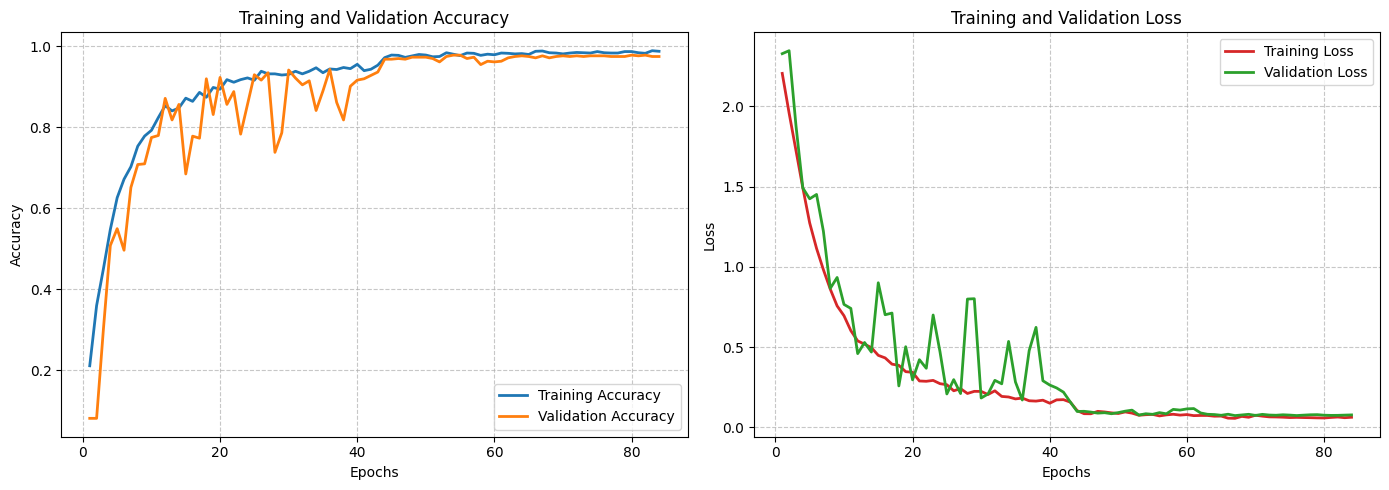

🚀 Đang tính toán dự đoán trên tập Validation...


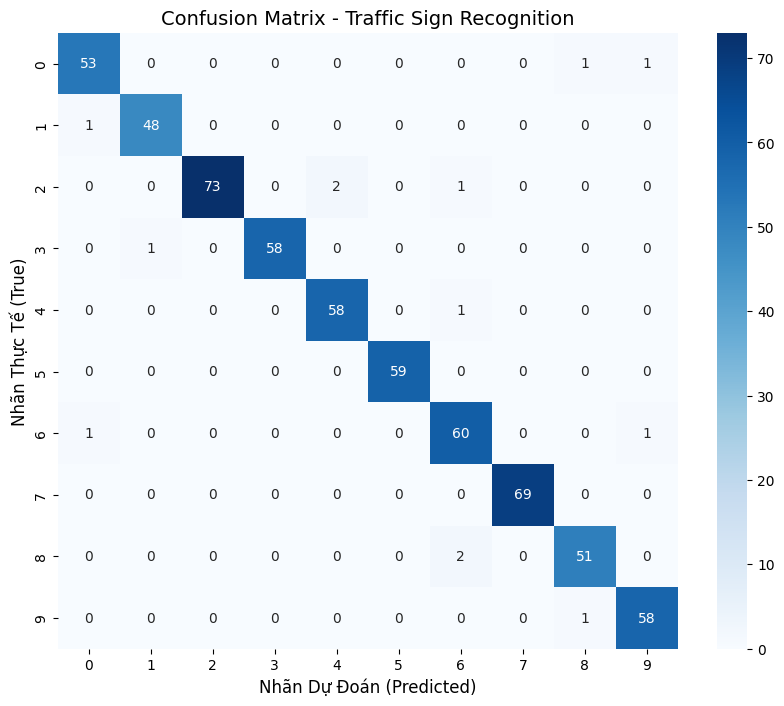

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ==========================================
# 1. HÀM VẼ BIỂU ĐỒ HISTORY (ACCURACY & LOSS)
# ==========================================
def plot_training_results(history):
    # Lấy dữ liệu từ object history của Keras
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Gọi hàm ngay sau khi qat_model.fit()
plot_training_results(history)


# ==========================================
# 2. VẼ CONFUSION MATRIX (MA TRẬN NHẦM LẪN)
# ==========================================
print("🚀 Đang tính toán dự đoán trên tập Validation...")

# Dự đoán nhãn từ qat_model (dùng tập val_ds)
y_pred = []
y_true = []

# Duyệt qua từng batch trong val_ds để lấy nhãn thật và nhãn dự đoán
for images, labels in val_ds:
    preds = qat_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Tính Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ nhiệt Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(NUM_CLASSES), 
            yticklabels=range(NUM_CLASSES))

plt.title('Confusion Matrix - Traffic Sign Recognition', fontsize=14)
plt.xlabel('Nhãn Dự Đoán (Predicted)', fontsize=12)
plt.ylabel('Nhãn Thực Tế (True)', fontsize=12)
plt.show()

c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


🚀 Đang chạy Inference bằng TFLite để vẽ Confusion Matrix...


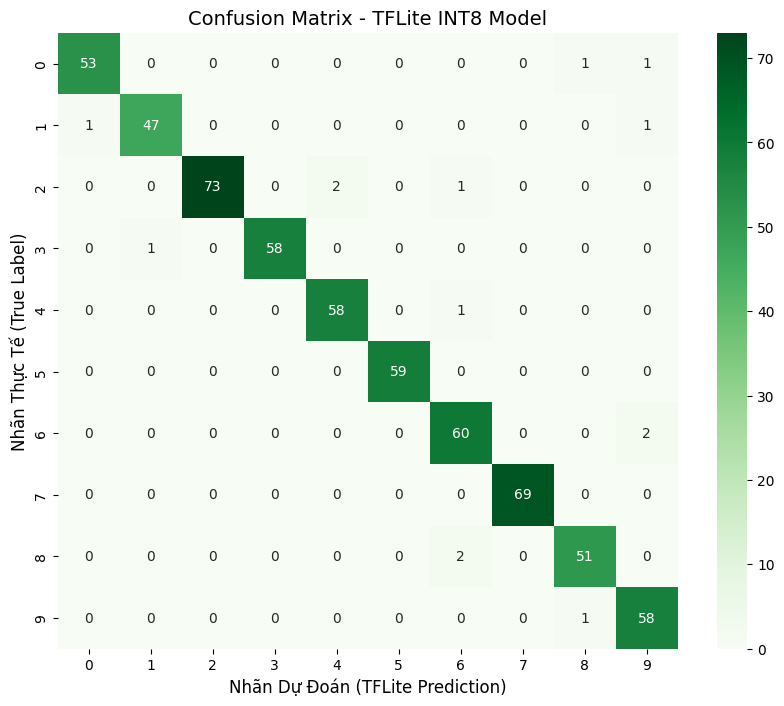

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Khởi tạo Interpreter từ file TFLite (INT8)
interpreter = tf.lite.Interpreter(model_path="traffic_sign_FINAL_INT8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_scale, input_zero_point = input_details[0]['quantization']

y_true_tflite = []
y_pred_tflite = []

print("🚀 Đang chạy Inference bằng TFLite để vẽ Confusion Matrix...")

# 2. Duyệt qua tập Validation
for images, labels in val_ds.unbatch():
    # Lấy ảnh và nhãn thực tế
    img_array = images.numpy()
    
    # TIỀN XỬ LÝ: Ép float (0-1) sang INT8 (Phải khớp với file TFLite)
    input_data = (img_array / input_scale + input_zero_point).astype(np.int8)
    input_data = np.expand_dims(input_data, axis=0)
    
    # CHẠY INFERENCE TFLITE
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])[0]
    
    # Lưu kết quả
    y_pred_tflite.append(np.argmax(output_data))
    y_true_tflite.append(labels.numpy())

# 3. VẼ BIỂU ĐỒ
cm_tflite = confusion_matrix(y_true_tflite, y_pred_tflite)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_tflite, annot=True, fmt='d', cmap='Greens', # Đổi sang màu xanh lá để phân biệt
            xticklabels=range(NUM_CLASSES), 
            yticklabels=range(NUM_CLASSES))

plt.title('Confusion Matrix - TFLite INT8 Model', fontsize=14)
plt.xlabel('Nhãn Dự Đoán (TFLite Prediction)', fontsize=12)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12)
plt.show()

# Log

In [19]:
# ==========================================
# TEST TFLITE MODEL & XUẤT CSV (BẢN CHUẨN DUT)
# ==========================================
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf

# 1. Load ĐÚNG file TFLite mới nhất bạn vừa convert thành công
# (Hãy đảm bảo tên file này khớp với file ở Cell Convert)
MODEL_PATH = "traffic_sign_final_int8.tflite" 
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# Lấy thông tin Input/Output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_index = input_details[0]['index']
output_index = output_details[0]['index']

# Lấy thông tin Quantization (Cực kỳ quan trọng cho INT8)
input_scale, input_zero_point = input_details[0]['quantization']

# 2. Quét danh sách ảnh Test
# Lưu ý: Sắp xếp theo tên để đảm bảo thứ tự trong CSV
test_images_paths = glob.glob(os.path.join(TEST_DIR, '*.png'))
test_images_paths.sort() 

results = []

print(f"🚀 Đang xử lý {len(test_images_paths)} ảnh test...")

for img_path in test_images_paths:
    # Lấy ID từ tên file (ví dụ: '001.png' -> '001')
    img_id = os.path.basename(img_path).split('.')[0]
    
    # --- TIỀN XỬ LÝ (Phải khớp 100% với lúc Train) ---
    # Load ảnh dạng GRAYSCALE (vì model của bạn train với color_mode='grayscale')
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale')
    img_array = tf.keras.utils.img_to_array(img)
    
    # Bước A: Rescaling 1./255 (giống normalization_layer lúc train)
    img_array = img_array / 255.0
    
    # Bước B: Quantization Scaling (Ép float sang INT8)
    if input_scale != 0:
        img_array = (img_array / input_scale) + input_zero_point
    
    # Thêm batch dimension và ép kiểu int8
    input_data = np.expand_dims(img_array.astype(np.int8), axis=0)
    
    # --- CHẠY INFERENCE ---
    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_index)[0]
    
    # Lấy class có xác suất cao nhất
    predicted_class = np.argmax(output_data)
    
    results.append({'Id': img_id, 'Label': int(predicted_class)})

# 3. XUẤT FILE CSV
submission_df = pd.DataFrame(results)

# Đảm bảo cột Id được lưu đúng định dạng (ví dụ 0001 thay vì 1 nếu cần)
submission_df.to_csv('submission_edge_ai.csv', index=False)

print("-" * 30)
print(f"✅ Đã xuất file thành công: submission_edge_ai.csv")
print(f"🔹 Tổng cộng: {len(submission_df)} dòng.")
print(submission_df.head()) # Xem trước 5 dòng đầu

c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


🚀 Đang xử lý 1000 ảnh test...
------------------------------
✅ Đã xuất file thành công: submission_edge_ai.csv
🔹 Tổng cộng: 1000 dòng.
      Id  Label
0  00000      4
1  00007      2
2  00012      2
3  00014      6
4  00022      1
